# Network Tutorial

This tutorial demonstrates how to use the `Network` class in Schema_skrf. The `Network` class provides a convenient way to work with n-port electrical networks, including creating, loading, and manipulating S-parameters.

In [1]:
import sys
from pathlib import Path

path = str(Path.cwd().parent)
if path not in sys.path:
    sys.path.append(path)

from Src.Models.Network import Network
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

## 1. Creating a Network

There are several ways to create a `Network` object:

### 1.1 Creating a Network from scratch

In [2]:
# Define frequency points
freq = np.linspace(1e9, 10e9, 101)  # 1-10 GHz, 101 points

# Create a simple 2-port network with all S-parameters = 0 (perfect isolation)
nports = 2
s_params = np.zeros((len(freq), nports, nports), dtype=complex)

# Set port impedances to 50 ohms
z0 = np.ones((len(freq), nports), dtype=complex) * 50.0

# Create the network
network = Network(
    frequency=freq,
    s_parameters=s_params,
    z0=z0,
    nports=nports,
    name="Simple 2-port Network",
    comments=["Created for tutorial"]
)

print(f"Created network: {network.name}")
print(f"Number of ports: {network.nports}")
print(f"Frequency range: {network.frequency[0]/1e9:.1f} - {network.frequency[-1]/1e9:.1f} GHz")

Created network: Simple 2-port Network
Number of ports: 2
Frequency range: 1.0 - 10.0 GHz


### 1.2 Loading a Network from a Touchstone file

In [3]:
# Load a network from a touchstone file
touchstone_path = "../Data/Touchstone/Lumped Elements_smatrix_tidy3d-RF.s4p"
network_from_file = Network.from_touchstone(touchstone_path)

print(f"Loaded network from file")
print(f"Number of ports: {network_from_file.nports}")
print(f"Frequency range: {network_from_file.frequency[0]/1e9:.1f} - {network_from_file.frequency[-1]/1e9:.1f} GHz")

Loaded network from file
Number of ports: 4
Frequency range: 0.1 - 4.8 GHz


### 1.3 Creating a Network from an existing scikit-rf Network

In [4]:
# Create a scikit-rf network
freq_object = rf.Frequency(1, 10, 101, unit='ghz')
skrf_network = rf.Network(frequency=freq_object, s=np.random.rand(101, 2, 2), name="scikit-rf Network")

# Convert to our Network class
network_from_skrf = Network.from_network(skrf_network)

print(f"Created network from scikit-rf: {network_from_skrf.name}")
print(f"Number of ports: {network_from_skrf.nports}")
print(f"Frequency range: {network_from_skrf.frequency[0]/1e9:.1f} - {network_from_skrf.frequency[-1]/1e9:.1f} GHz")

Created network from scikit-rf: scikit-rf Network
Number of ports: 2
Frequency range: 1.0 - 10.0 GHz


## 2. Working with Networks

Now let's look at how to work with the Network objects.

### 2.1 Accessing Network Properties

In [5]:
# Let's work with the network we loaded from the touchstone file
print(f"Network name: {network_from_file.name}")
print(f"Number of frequency points: {len(network_from_file.frequency)}")
print(f"S-parameter shape: {network_from_file.s_parameters.shape}")
print(f"Port impedances at first frequency: {network_from_file.z0[0]}")

Network name: Lumped Elements_smatrix_tidy3d-RF
Number of frequency points: 101
S-parameter shape: (101, 4, 4)
Port impedances at first frequency: [50.+0.j 50.+0.j 50.+0.j 50.+0.j]


### 2.2 Converting to scikit-rf Network for Analysis

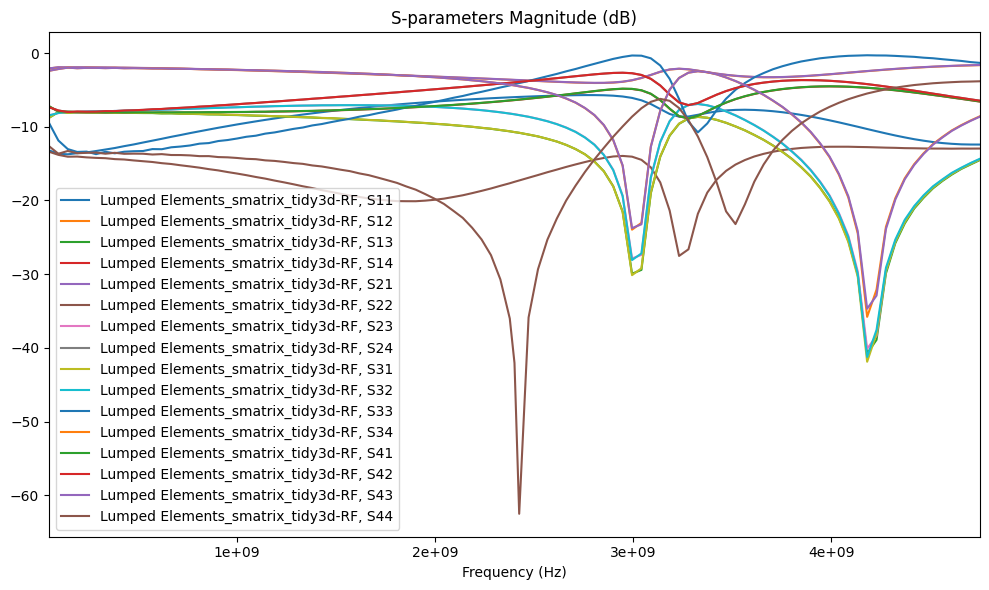

In [6]:
# Convert our Network to scikit-rf Network for additional analysis
skrf_net = network_from_file.to_network()

# Plot S-parameters
plt.figure(figsize=(10, 6))
skrf_net.plot_s_db()
plt.title("S-parameters Magnitude (dB)")
plt.tight_layout()
plt.show()

### 2.3 Frequency Interpolation

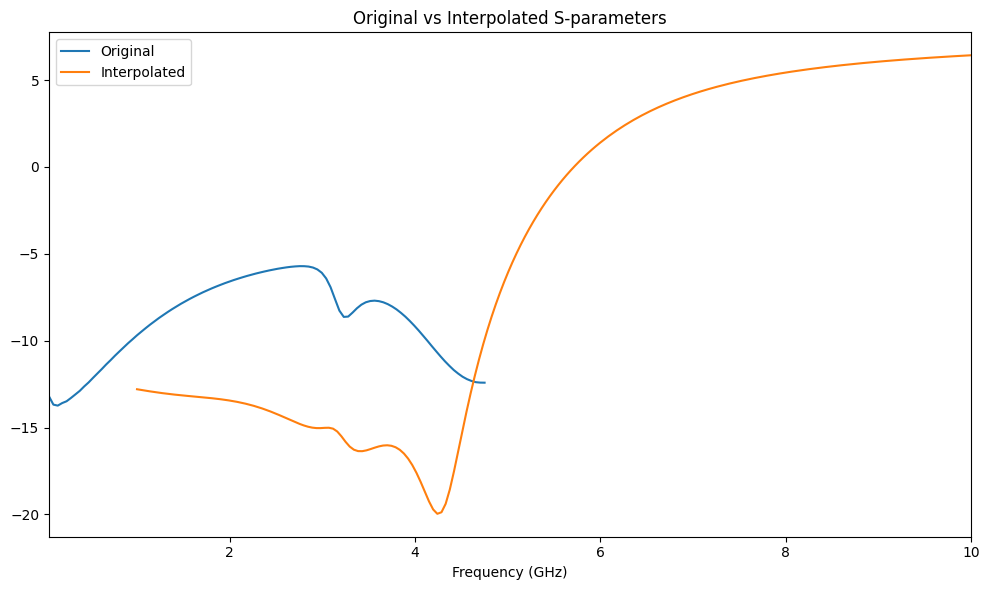

In [7]:
from Src.Models.Network import fit_frequency

# Create a new frequency range with more points
new_freq = rf.Frequency(1, 10, 201, unit='ghz')  # More points for smoother curves

# Interpolate the network to the new frequency range
interpolated_network = fit_frequency(skrf_net, new_freq)

# Plot original and interpolated networks
plt.figure(figsize=(10, 6))
skrf_net.plot_s_db(0, 0, label='Original')
interpolated_network.plot_s_db(0, 0, label='Interpolated')
plt.title("Original vs Interpolated S-parameters")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Practical Example: Analyzing a Circuit with Networks

10:59:58 EDT ERROR: Expected 2 dimensions for ArrayLike, got 1.                 

             ERROR: Expected 2 dimensions for ArrayLike, got 1.                 

             ERROR: Expected 2 dimensions for ArrayLike, got 1.                 

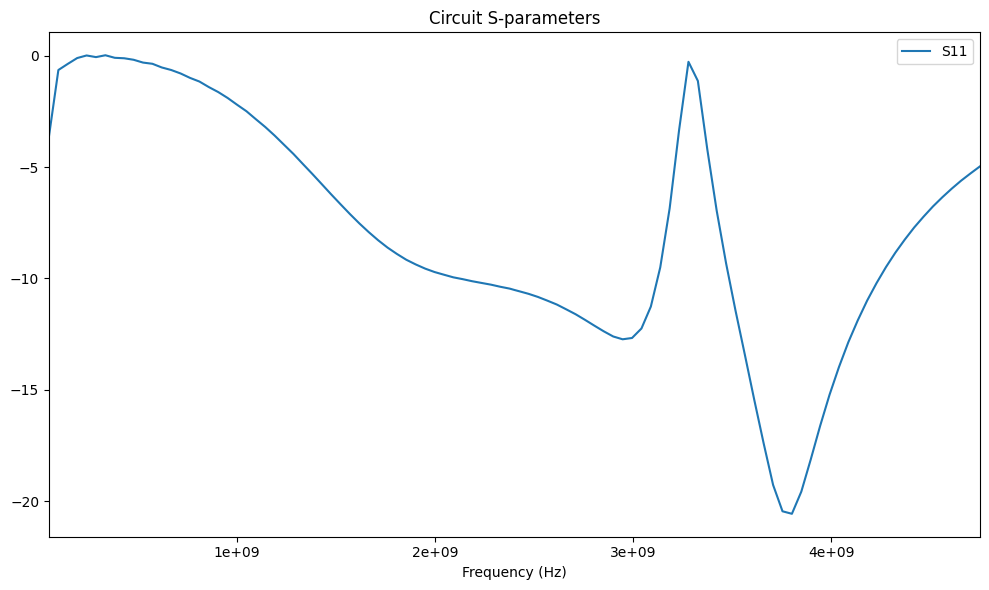

In [8]:
from Src.Models.Component import Port, Ground
from Src.Models.Circuit import Circuit

# Load a 4-port network from a touchstone file
rf_snp = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_tidy3d-RF.s4p")

# Create port and ground components
port1 = Port(name='port1', frequency=rf_snp.frequency, z0=[50.0, 0.0])
gnd1 = Ground(name='gnd1', frequency=rf_snp.frequency, z0=[50.0, 0.0])
gnd2 = Ground(name='gnd2', frequency=rf_snp.frequency, z0=[50.0, 0.0])

# Define the networks in our circuit
networks = {
    'port1': port1,
    'gnd1': gnd1,
    'gnd2': gnd2,
    'rf_snp': rf_snp
}

# Define the connections between networks
connections = [
    [
        ('port1', 0),
        ('rf_snp', 0)
    ],
    [
        ('gnd1', 0),
        ('rf_snp', 1)
    ],
    [
        ('gnd2', 0),
        ('rf_snp', 2)
    ],
]

# Create the circuit
rf_circuit = Circuit(networks=networks, connections=connections)

# Convert to scikit-rf circuit for analysis
skrf_circuit = rf_circuit.to_circuit()

# Plot the S-parameters of the circuit
plt.figure(figsize=(10, 6))
skrf_circuit.network.plot_s_db()
plt.title("Circuit S-parameters")
plt.tight_layout()
plt.show()

## 4. Comparing with Reference Data

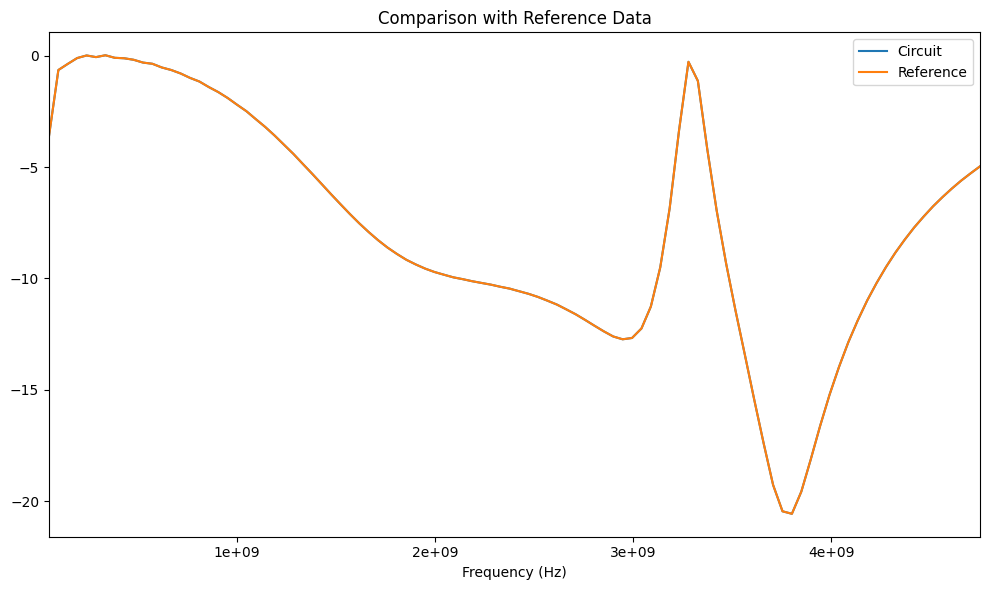

In [9]:
# Load a reference network for comparison
reference = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_cascaded_1_tidy3d-RF.s1p")
reference_skrf = reference.to_network()

# Plot both for comparison
plt.figure(figsize=(10, 6))
skrf_circuit.network.plot_s_db(0, 0, label='Circuit')
reference_skrf.plot_s_db(0, 0, label='Reference')
plt.title("Comparison with Reference Data")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Summary

In this tutorial, we've covered:

1. Creating Network objects from scratch, from Touchstone files, and from scikit-rf Network objects
2. Accessing Network properties
3. Converting to scikit-rf Network for analysis and visualization
4. Frequency interpolation
5. Building and analyzing circuits with multiple networks
6. Comparing circuit results with reference data

The Network class provides a convenient interface for working with n-port electrical networks in Schema_skrf, with seamless integration with scikit-rf for advanced analysis and visualization.